# Detecção de Discurso de Ódio com Embeddings Instrucionais
### Comparação entre: sem instrução, instrução manual e instrução gerada automaticamente por LLM

## 1. Requisitos e Configurações

In [ ]:
%pip install -q "sentence-transformers>=3,<6" "scikit-learn>=1.5,<2" "requests>=2.32,<3" "seaborn>=0.13,<1" "tqdm>=4.66,<5"

In [ ]:
import os
import time
import json
import pickle
import threading
import numpy as np
import pandas as pd
import requests
from pathlib import Path
from collections import deque
from sentence_transformers import SentenceTransformer
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import gc, hashlib, platform, re, shutil, sys, urllib.request
from collections.abc import Iterable, Sequence
from dataclasses import dataclass
from typing import Any
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_colwidth",120); sns.set_theme(style="whitegrid")
try:
 import torch
 DEVICE_INFO=torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
except ImportError: DEVICE_INFO="CPU"
print("Python:",sys.version.split()[0],"| Dispositivo:",DEVICE_INFO)

Python: 3.12.13 | Dispositivo: CPU


**Configurações gerais do experimento.**

Escolhi usar o Groq pq a chave é gratuita: https://console.groq.com/keys


In [ ]:
import os
os.environ["GROQ_API_KEY"] ="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" #expira dia 15/ago

In [ ]:
# Configurações Gerais
SEED = 42
np.random.seed(SEED)

DATA_PATH = "HateBR.csv"
TEXT_COL = "comentario"
LABEL_COL = "label_final"
ACCOUNT_COL = "account_post"

# 1) e5_multilingual: modelo principal, treinado para seguir instrução
# 2) e5_large_instruct: segundo modelo treinado para seguir instrução (mesma família, maior e com fine-tuning instrucional mais extenso)
# 3) bertimbau_pt: modelo específico de português, mas SEM treinamento para seguir instrução. Serve apenaspara mostrar se o padrão de erro do classificador se mantém mesmo trocando o modelo de embeddings/idioma de treinamento.

# "estilo_instrucao: define como a instrução é combinada com o texto do comentário:
#   - "e5": segue o formato nativo de instrução do E5 ("Instruct: ...\nQuery: ...").
#   - "prefixo_simples": a instrução é apenas concatenada como frase antes do comentário. Mantido apenas para a checagem de robustez do classificador.

# "segue_instrucao" (bool): marca explicitamente quais modelos foram de fato treinados para seguir instrução -- usado mais adiante para não misturar as duas perguntas de pesquisa nas conclusões.

# "idioma": define em que língua a instrução é escrita/gerada para aquele modelo

MODELOS_EMBEDDING = {
    "e5_multilingual": {
        "path": "intfloat/multilingual-e5-base",
        "descricao": "Multilingual E5-base (multilíngue, treinado para seguir instruções)",
        "estilo_instrucao": "e5",
        "idioma": "en",
        "segue_instrucao": True,
    },
    "e5_large_instruct": {
        "path": "intfloat/multilingual-e5-large-instruct",
        "descricao": "Multilingual E5-large-instruct (multilíngue, fine-tuning instrucional mais extenso; segundo modelo p/ repetir a pergunta central)",
        "estilo_instrucao": "e5",
        "idioma": "en",
        "segue_instrucao": True,
    },
    "bertimbau_pt": {
        "path": "rufimelo/bert-large-portuguese-cased-sts",
        "descricao": "BERTimbau-large-STS (específico do português brasileiro; NÃO treinado para seguir instruções, usado só como controle de robustez do classificador)",
        "estilo_instrucao": "prefixo_simples",
        "idioma": "pt",
        "segue_instrucao": False,
    },
}

MODELOS_INSTRUCIONAIS = [
    nome for nome, cfg in MODELOS_EMBEDDING.items() if cfg["segue_instrucao"]
]
MODELOS_CONTROLE = [
    nome for nome, cfg in MODELOS_EMBEDDING.items() if not cfg["segue_instrucao"]
]
IDIOMAS_USADOS = sorted({cfg["idioma"] for cfg in MODELOS_EMBEDDING.values()})
CONDICOES = ("sem_instrucao", "instrucao_manual", "instrucao_automatica")


# Diretório de cache: guarda embeddings e instruções já geradas
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# LLM (Groq) para geração automática de instruções
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
GROQ_MODEL = "llama-3.1-8b-instant"
GROQ_URL = "https://api.groq.com/openai/v1/chat/completions"


BATCH_SIZE = 10   # comentários por chamada de API
MAX_WORKERS = 4   # chamadas concorrentes
RPM_LIMIT = 25


## 2. Carregamento e Pré-processamento dos Dados

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Shape original: {df.shape}")
df.head(15)

Shape original: (7000, 8)


,id,comentario,anotator1,anotator2,anotator3,label_final,links_post,account_post
0,1,Mais um lixo,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
1,2,Essa nao tem vergonha na cara!!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
2,3,Essa mulher é doente.pilantra!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
3,4,Comunista safada...,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
4,5,Vagabunda. Comunista. Mentirosa. O povo chileno nao merece uma desgraça desta.,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
5,6,"COMUNISTA SAFADA, MALPARIDA, MAMAGUEVA, DESGRAÇADA, COÑO É TU MADRE.",1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
6,7,Besta quadrada.,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
7,8,Se elegeu as nossas custas,1,0,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
8,9,Comunista lixo!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
9,10,"Quem tem pena é galinha, mas ela é uma VACA LOUCA.",1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli


Contas únicas: 6 | Posts únicos: 78


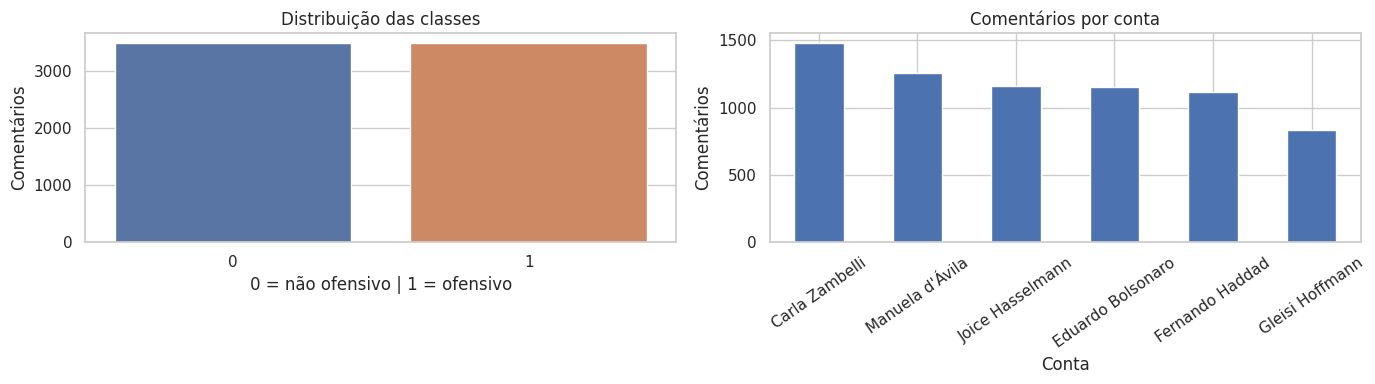

,comentarios
account_post,
Carla Zambelli,1481
Manuela d'Ávila,1258
Joice Hasselmann,1158
Eduardo Bolsonaro,1151
Fernando Haddad,1118
Gleisi Hoffmann,834


In [ ]:
print("Contas únicas:",df.account_post.nunique(),"| Posts únicos:",df.links_post.nunique())
fig,axes=plt.subplots(1,2,figsize=(14,4))
sns.countplot(data=df,x=LABEL_COL,hue=LABEL_COL,legend=False,ax=axes[0])
axes[0].set(title="Distribuição das classes",xlabel="0 = não ofensivo | 1 = ofensivo",ylabel="Comentários")
df.account_post.value_counts().plot(kind="bar",ax=axes[1],color="#4C72B0")
axes[1].set(title="Comentários por conta",xlabel="Conta",ylabel="Comentários"); axes[1].tick_params(axis="x",rotation=35)
plt.tight_layout(); plt.show(); display(df.account_post.value_counts().rename("comentarios").to_frame())

In [ ]:
# Remoção de registros vazios/nulos
linhas_antes = len(df)

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip() != ""]
df = df.reset_index(drop=True)

print(f"Registros removidos (vazios/nulos): {linhas_antes - len(df)}")
print(f"Shape final: {df.shape}")

Registros removidos (vazios/nulos): 0
Shape final: (7000, 8)


In [ ]:
def dividir_dados(dados):
    try:
        treino, temporario = train_test_split(
            dados,
            test_size=0.30,
            stratify=dados[LABEL_COL],
            random_state=SEED,
        )
        validacao, teste = train_test_split(
            temporario,
            test_size=0.50,
            stratify=temporario[LABEL_COL],
            random_state=SEED,
        )
    except ValueError as erro:
        raise ValueError(
            "Não foi possível realizar a divisão estratificada. Verifique se "
            "cada classe possui exemplos suficientes."
        ) from erro

    return (
        treino.reset_index(drop=True),
        validacao.reset_index(drop=True),
        teste.reset_index(drop=True),
    )


train, valid, test = dividir_dados(df)
print(f"Treino: {len(train)} | Validação: {len(valid)} | Teste: {len(test)}")

Treino: 4900 | Validação: 1050 | Teste: 1050


## 3. Modelos de Embeddings

In [ ]:
modelos = {}

for chave, cfg in MODELOS_EMBEDDING.items():
    print(f"Carregando {chave}: {cfg['path']} ...")
    modelos[chave] = SentenceTransformer(cfg["path"])

print("\nTodos os modelos de embeddings foram carregados:")

for chave, cfg in MODELOS_EMBEDDING.items():
    papel = "instrucional" if cfg["segue_instrucao"] else "controle (não segue instrução)"
    print(f" - {chave} [{papel}]: {cfg['descricao']}")

Carregando e5_multilingual: intfloat/multilingual-e5-base ...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/678k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Invalid model-index. Not loading eval results into CardData.



Todos os modelos de embeddings foram carregados:
 - e5_multilingual [instrucional]: Multilingual E5-base (multilíngue, treinado para seguir instruções)
 - e5_large_instruct [instrucional]: Multilingual E5-large-instruct (multilíngue, fine-tuning instrucional mais extenso; segundo modelo p/ repetir a pergunta central)
 - bertimbau_pt [controle (não segue instrução)]: BERTimbau-large-STS (específico do português brasileiro; NÃO treinado para seguir instruções, usado só como controle de robustez do classificador)


## 4. Definição das Instruções

### 4.1 Instrução Manual (fixa)


In [ ]:
manual_instruction_en = (
    "Represent the following Brazilian Portuguese comment for hate speech detection. "
    "Pay attention to insults, discrimination, prejudice, attacks against minorities and offensive language."
) # instrução em inglês, usada nos modelos instrucionais treinados em inglês (e5_multilingual, e5_large_instruct)

manual_instruction_pt = (
    "Represente o seguinte comentário em português brasileiro para detecção de discurso de ódio. "
    "Preste atenção a insultos, discriminação, preconceito, ataques a minorias e linguagem ofensiva."
) # instrução em português, usada no modelo específico de português (BERTimbau)

MANUAL_INSTRUCTION_POR_IDIOMA = {
    "en": manual_instruction_en,
    "pt": manual_instruction_pt,
}

### 4.2 Instrução Automática (gerada por LLM)

Para cada comentário, pedimos para a LLM que gere uma instrução curta e específica sobre o que observar naquele comentário.

In [ ]:
class RateLimiter:

    def __init__(self, max_per_minute):
        self.max_per_minute = max_per_minute
        self.lock = threading.Lock()
        self.timestamps = []

    def wait(self):
        with self.lock:
            agora = time.time()
            self.timestamps = [t for t in self.timestamps if agora - t < 60]
            if len(self.timestamps) >= self.max_per_minute:
                espera = 60 - (agora - self.timestamps[0]) + 0.1
            else:
                espera = 0
            self.timestamps.append(agora + espera)
        if espera > 0:
            time.sleep(espera)


rate_limiter = RateLimiter(max_per_minute=RPM_LIMIT)

In [ ]:
def gerar_instrucao_automatica(texto, idioma="en", max_retries=3):
    if GROQ_API_KEY is None:
        raise RuntimeError(
            "GROQ_API_KEY não encontrada. Defina a variável de ambiente antes de rodar esta célula."
        )

    if idioma == "pt":
        prompt = (
            "Você receberá um comentário em português brasileiro. "
            "Escreva UMA instrução curta (máx. 25 palavras), em português, dizendo a um modelo de "
            "embeddings o que observar NESTE comentário específico para detectar discurso de ódio. "
            "Responda apenas com a instrução, nada mais.\n\n"
            f"Comentário: {texto}"
        )
    else:
        prompt = (
            "You will receive a comment in Brazilian Portuguese. "
            "Write ONE short instruction (max 25 words), in English, telling an embedding model "
            "what to pay attention to in THIS specific comment in order to detect hate speech. "
            "Output only the instruction, nothing else.\n\n"
            f"Comment: {texto}"
        )

    headers = {"Authorization": f"Bearer {GROQ_API_KEY}"}
    payload = {
        "model": GROQ_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.2,
        "max_tokens": 60,
    }

    for tentativa in range(max_retries):
        rate_limiter.wait()
        try:
            resp = requests.post(GROQ_URL, headers=headers, json=payload, timeout=30)
            if resp.status_code == 429:
                time.sleep(5 * (tentativa + 1))
                continue
            resp.raise_for_status()
            return resp.json()["choices"][0]["message"]["content"].strip()
        except Exception as e:
            print(f"Tentativa {tentativa+1} falhou para: {texto[:50]}... | erro: {e}")
            time.sleep(2)

    return None

In [ ]:
def gerar_instrucoes_lote_llm(lista_textos, idioma="en", max_retries=3): ## isso aqui é uma tentativa de otimizar pq tava demorando demais

    if GROQ_API_KEY is None:
        raise RuntimeError(
            "GROQ_API_KEY não encontrada. Defina a variável de ambiente antes de rodar esta célula."
        )

    itens = "\n".join(f"{i+1}. {t}" for i, t in enumerate(lista_textos))

    if idioma == "pt":
        prompt = (
            "Você receberá uma lista numerada de comentários em português brasileiro.\n"
            "Para CADA comentário, escreva UMA instrução curta (máx. 25 palavras), em português, "
            "dizendo a um modelo de embeddings o que observar NAQUELE comentário específico para "
            "detectar discurso de ódio.\n"
            "Retorne APENAS um array JSON de strings, na MESMA ordem e MESMO tamanho da lista de "
            "entrada, sem texto extra, sem markdown, sem numeração.\n\n"
            f"{itens}"
        )
    else:
        prompt = (
            "You will receive a numbered list of comments in Brazilian Portuguese.\n"
            "For EACH comment, write ONE short instruction (max 25 words), in English, telling an "
            "embedding model what to pay attention to in THAT specific comment to detect hate speech.\n"
            "Return ONLY a JSON array of strings, in the SAME order and SAME length as the input list, "
            "with no extra text, no markdown, no numbering.\n\n"
            f"{itens}"
        )

    headers = {"Authorization": f"Bearer {GROQ_API_KEY}"}
    payload = {
        "model": GROQ_MODEL,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.2,
        "max_tokens": 60 * len(lista_textos),
    }

    for tentativa in range(max_retries):
        rate_limiter.wait()
        try:
            resp = requests.post(GROQ_URL, headers=headers, json=payload, timeout=60)
            if resp.status_code == 429:
                time.sleep(5 * (tentativa + 1))
                continue
            resp.raise_for_status()

            texto_resp = resp.json()["choices"][0]["message"]["content"].strip()
            texto_resp = texto_resp.strip("`")
            if texto_resp.lower().startswith("json"):
                texto_resp = texto_resp[4:].strip()

            instrucoes = json.loads(texto_resp)
            if isinstance(instrucoes, list) and len(instrucoes) == len(lista_textos):
                return instrucoes

            print(
                f"Tamanho inesperado na resposta do lote "
                f"(esperado {len(lista_textos)}, recebido "
                f"{len(instrucoes) if isinstance(instrucoes, list) else 'formato inválido'})"
            )
        except Exception as e:
            print(f"Tentativa {tentativa+1} falhou para lote de {len(lista_textos)} comentários | erro: {e}")
            time.sleep(2)

    # Fallback: se o lote falhar em todas as tentativas, gera comentário por comentário
    print("Fallback: gerando este lote comentário por comentário (mais lento, porém confiável).")
    return [gerar_instrucao_automatica(t) for t in lista_textos]

In [ ]:
def gerar_instrucoes_em_lote(comentarios, cache_file, idioma="en", batch_size=BATCH_SIZE, max_workers=MAX_WORKERS):
    cache_path = CACHE_DIR / cache_file

    if cache_path.exists():
        instrucoes = json.load(open(cache_path, encoding="utf-8"))
    else:
        instrucoes = {}

    pendentes = [t for t in comentarios if t not in instrucoes]
    lotes = [pendentes[i:i + batch_size] for i in range(0, len(pendentes), batch_size)]
    print(f"[{idioma}] {len(pendentes)} comentários pendentes em {len(lotes)} lotes de até {batch_size}")

    lock = threading.Lock()
    concluidos = 0

    def processar_lote(lote):
        return lote, gerar_instrucoes_lote_llm(lote, idioma=idioma)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(processar_lote, lote) for lote in lotes]

        for future in tqdm(as_completed(futures), total=len(lotes), desc=f"Gerando instruções ({cache_file})"):
            lote, resultado = future.result()
            with lock:
                for texto, instrucao in zip(lote, resultado):
                    instrucoes[texto] = instrucao
                concluidos += 1
                if concluidos % 5 == 0:
                    json.dump(instrucoes, open(cache_path, "w", encoding="utf-8"), ensure_ascii=False)

    json.dump(instrucoes, open(cache_path, "w", encoding="utf-8"), ensure_ascii=False)
    return instrucoes

In [ ]:
# Gerando instruções automáticas para os três splits, em cada idioma usado pelos modelos
# (inglês para os modelos instrucionais e5_multilingual/e5_large_instruct, português para o BERTimbau)
instrucoes_auto = {}  # instrucoes_auto[idioma][split] = {comentario: instrucao}

for idioma in IDIOMAS_USADOS:
    instrucoes_auto[idioma] = {
        "train": gerar_instrucoes_em_lote(train[TEXT_COL].tolist(), f"auto_instrucoes_train_{idioma}.json", idioma=idioma),
        "valid": gerar_instrucoes_em_lote(valid[TEXT_COL].tolist(), f"auto_instrucoes_valid_{idioma}.json", idioma=idioma),
        "test":  gerar_instrucoes_em_lote(test[TEXT_COL].tolist(),  f"auto_instrucoes_test_{idioma}.json",  idioma=idioma),
    }

[en] 0 comentários pendentes em 0 lotes de até 10


Gerando instruções (auto_instrucoes_train_en.json): 0it [00:00, ?it/s]


[en] 0 comentários pendentes em 0 lotes de até 10


Gerando instruções (auto_instrucoes_valid_en.json): 0it [00:00, ?it/s]


[en] 0 comentários pendentes em 0 lotes de até 10


...

Gerando instruções (auto_instrucoes_train_pt.json): 0it [00:00, ?it/s]


[pt] 0 comentários pendentes em 0 lotes de até 10


Gerando instruções (auto_instrucoes_valid_pt.json): 0it [00:00, ?it/s]


[pt] 0 comentários pendentes em 0 lotes de até 10


Gerando instruções (auto_instrucoes_test_pt.json): 0it [00:00, ?it/s]


## 5. Geração de Embeddings para as Três Condições

In [ ]:
def formatar_entrada(texto, instrucao, estilo): # Combina o comentário com a instrução de acordo com o estilo esperado pelo modelo.
    if estilo == "e5":
        if instrucao:
            return f"Instruct: {instrucao}\nQuery: {texto}"
        return f"query: {texto}"
    elif estilo == "prefixo_simples":
        # Modelos sem treinamento para seguir instruções: a instrução é apenas concatenada como uma frase de contexto antes do comentário.
        if instrucao:
            return f"{instrucao} {texto}"
        return texto
    else:
        raise ValueError(f"Estilo de instrução desconhecido: {estilo}")


def gerar_embeddings(chave_modelo, textos, instrucao=None, instrucoes_por_texto=None, batch_size=64):
    cfg = MODELOS_EMBEDDING[chave_modelo]
    modelo = modelos[chave_modelo]
    estilo = cfg["estilo_instrucao"]

    entradas = []
    for texto in textos:
        if instrucoes_por_texto is not None:
            inst = instrucoes_por_texto.get(texto)
        else:
            inst = instrucao
        entradas.append(formatar_entrada(texto, inst, estilo))

    return modelo.encode(
        entradas,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    )

In [ ]:
def obter_embeddings_com_cache(chave_modelo, nome_condicao, split_nome, textos, **kwargs):
    cache_path = CACHE_DIR / f"emb_{chave_modelo}_{nome_condicao}_{split_nome}.npy"
    if cache_path.exists():
        return np.load(cache_path)
    emb = gerar_embeddings(chave_modelo, textos, **kwargs)
    np.save(cache_path, emb)
    return emb

In [ ]:
CONDICOES = ["sem_instrucao", "instrucao_manual", "instrucao_automatica"]

# EMBEDDINGS[(chave_modelo, condicao)] = (X_train, X_valid, X_test)
EMBEDDINGS = {}

for chave_modelo, cfg in MODELOS_EMBEDDING.items():
    idioma = cfg["idioma"]
    manual_instr = MANUAL_INSTRUCTION_POR_IDIOMA[idioma]
    auto_instr_train = instrucoes_auto[idioma]["train"]
    auto_instr_valid = instrucoes_auto[idioma]["valid"]
    auto_instr_test  = instrucoes_auto[idioma]["test"]

    # Baseline: sem instrução
    X_tr_base = obter_embeddings_com_cache(chave_modelo, "sem_instrucao", "train", train[TEXT_COL].tolist())
    X_va_base = obter_embeddings_com_cache(chave_modelo, "sem_instrucao", "valid", valid[TEXT_COL].tolist())
    X_te_base = obter_embeddings_com_cache(chave_modelo, "sem_instrucao", "test",  test[TEXT_COL].tolist())
    EMBEDDINGS[(chave_modelo, "sem_instrucao")] = (X_tr_base, X_va_base, X_te_base)

    # Instrução manual
    X_tr_man = obter_embeddings_com_cache(
        chave_modelo, "instrucao_manual", "train", train[TEXT_COL].tolist(), instrucao=manual_instr
    )
    X_va_man = obter_embeddings_com_cache(
        chave_modelo, "instrucao_manual", "valid", valid[TEXT_COL].tolist(), instrucao=manual_instr
    )
    X_te_man = obter_embeddings_com_cache(
        chave_modelo, "instrucao_manual", "test", test[TEXT_COL].tolist(), instrucao=manual_instr
    )
    EMBEDDINGS[(chave_modelo, "instrucao_manual")] = (X_tr_man, X_va_man, X_te_man)

    # # Instrução Automática (LLM)
    X_tr_auto = obter_embeddings_com_cache(
        chave_modelo, "instrucao_automatica", "train", train[TEXT_COL].tolist(), instrucoes_por_texto=auto_instr_train
    )
    X_va_auto = obter_embeddings_com_cache(
        chave_modelo, "instrucao_automatica", "valid", valid[TEXT_COL].tolist(), instrucoes_por_texto=auto_instr_valid
    )
    X_te_auto = obter_embeddings_com_cache(
        chave_modelo, "instrucao_automatica", "test", test[TEXT_COL].tolist(), instrucoes_por_texto=auto_instr_test
    )
    EMBEDDINGS[(chave_modelo, "instrucao_automatica")] = (X_tr_auto, X_va_auto, X_te_auto)

    print(f"[{chave_modelo}] embeddings gerados para as 3 condições.")

y_train = train[LABEL_COL].values
y_valid = valid[LABEL_COL].values
y_test = test[LABEL_COL].values

[e5_multilingual] embeddings gerados para as 3 condições.
[e5_large_instruct] embeddings gerados para as 3 condições.
[bertimbau_pt] embeddings gerados para as 3 condições.


## 6. Treinamento dos Classificadores

In [ ]:
# Um classificador por combinação (3 modelos de embeddings x 3 condições de instrução) = 9 classificadores
classificadores = {}  # classificadores[(chave_modelo, condicao)] = clf

for chave_modelo in MODELOS_EMBEDDING:
    for condicao in CONDICOES:
        X_tr, X_val, X_te = EMBEDDINGS[(chave_modelo, condicao)]
        clf = MLPClassifier(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            max_iter=300,
            early_stopping=True,
            random_state=SEED,
        )
        clf.fit(X_tr, y_train)
        classificadores[(chave_modelo, condicao)] = clf
        print(f"[{chave_modelo} | {condicao}] convergiu em {clf.n_iter_} iterações")

[e5_multilingual | sem_instrucao] convergiu em 34 iterações
[e5_multilingual | instrucao_manual] convergiu em 43 iterações
[e5_multilingual | instrucao_automatica] convergiu em 32 iterações
[e5_large_instruct | sem_instrucao] convergiu em 19 iterações
[e5_large_instruct | instrucao_manual] convergiu em 41 iterações
[e5_large_instruct | instrucao_automatica] convergiu em 25 iterações
[bertimbau_pt | sem_instrucao] convergiu em 16 iterações
[bertimbau_pt | instrucao_manual] convergiu em 30 iterações
[bertimbau_pt | instrucao_automatica] convergiu em 26 iterações


## 7. Avaliação e Comparação entre Condições

Reporta accuracy, precision/recall/F1 *weighted* e **F1-macro** para cada uma das 9 combinações


In [ ]:
def avaliar(clf, X, y):
    y_pred = clf.predict(X)
    metrics = {
        "accuracy": accuracy_score(y, y_pred),
        "precision_weighted": precision_score(y, y_pred, average="weighted"),
        "recall_weighted": recall_score(y, y_pred, average="weighted"),
        "f1_weighted": f1_score(y, y_pred, average="weighted"),
        "f1_macro": f1_score(y, y_pred, average="macro"),
    }
    return metrics, y_pred

In [ ]:
resultados = []
predicoes_teste = {}

for chave_modelo in MODELOS_EMBEDDING:
    for condicao in CONDICOES:
        X_tr, X_val, X_te = EMBEDDINGS[(chave_modelo, condicao)]
        clf = classificadores[(chave_modelo, condicao)]

        metrics_valid, _ = avaliar(clf, X_val, y_valid)
        metrics_test, y_pred_test = avaliar(clf, X_te, y_test)

        resultados.append({"modelo": chave_modelo, "condicao": condicao, "split": "validação", **metrics_valid})
        resultados.append({"modelo": chave_modelo, "condicao": condicao, "split": "teste", **metrics_test})

        predicoes_teste[(chave_modelo, condicao)] = y_pred_test

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(["modelo", "condicao", "split"]).reset_index(drop=True)
df_resultados

,modelo,condicao,split,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro
0,bertimbau_pt,instrucao_automatica,teste,0.888571,0.888607,0.888571,0.888569,0.888569
1,bertimbau_pt,instrucao_automatica,validação,0.870476,0.870670,0.870476,0.870459,0.870459
2,bertimbau_pt,instrucao_manual,teste,0.893333,0.893699,0.893333,0.893309,0.893309
3,bertimbau_pt,instrucao_manual,validação,0.889524,0.889546,0.889524,0.889522,0.889522
4,bertimbau_pt,sem_instrucao,teste,0.881905,0.882354,0.881905,0.881870,0.881870
5,bertimbau_pt,sem_instrucao,validação,0.881905,0.881910,0.881905,0.881904,0.881904
6,e5_large_instruct,instrucao_automatica,teste,0.871429,0.872024,0.871429,0.871377,0.871377
7,e5_large_instruct,instrucao_automatica,validação,0.864762,0.865404,0.864762,0.864703,0.864703
8,e5_large_instruct,instrucao_manual,teste,0.899048,0.905455,0.899048,0.898647,0.898647
9,e5_large_instruct,instrucao_manual,validação,0.885714,0.891170,0.885714,0.885314,0.885314


In [ ]:
# Relatório de classificação para as 9 combinações
for (chave_modelo, condicao), y_pred in predicoes_teste.items():
    print(f"\n=== {chave_modelo} | {condicao} ===")
    print(classification_report(y_test, y_pred))


=== e5_multilingual | sem_instrucao ===
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       525
           1       0.88      0.87      0.88       525

    accuracy                           0.88      1050
   macro avg       0.88      0.88      0.88      1050
weighted avg       0.88      0.88      0.88      1050


=== e5_multilingual | instrucao_manual ===
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       525
           1       0.86      0.86      0.86       525

    accuracy                           0.86      1050
   macro avg       0.86      0.86      0.86      1050
weighted avg       0.86      0.86      0.86      1050


=== e5_multilingual | instrucao_automatica ===
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       525
           1       0.87      0.88      0.87       525

    accuracy                           0.87      

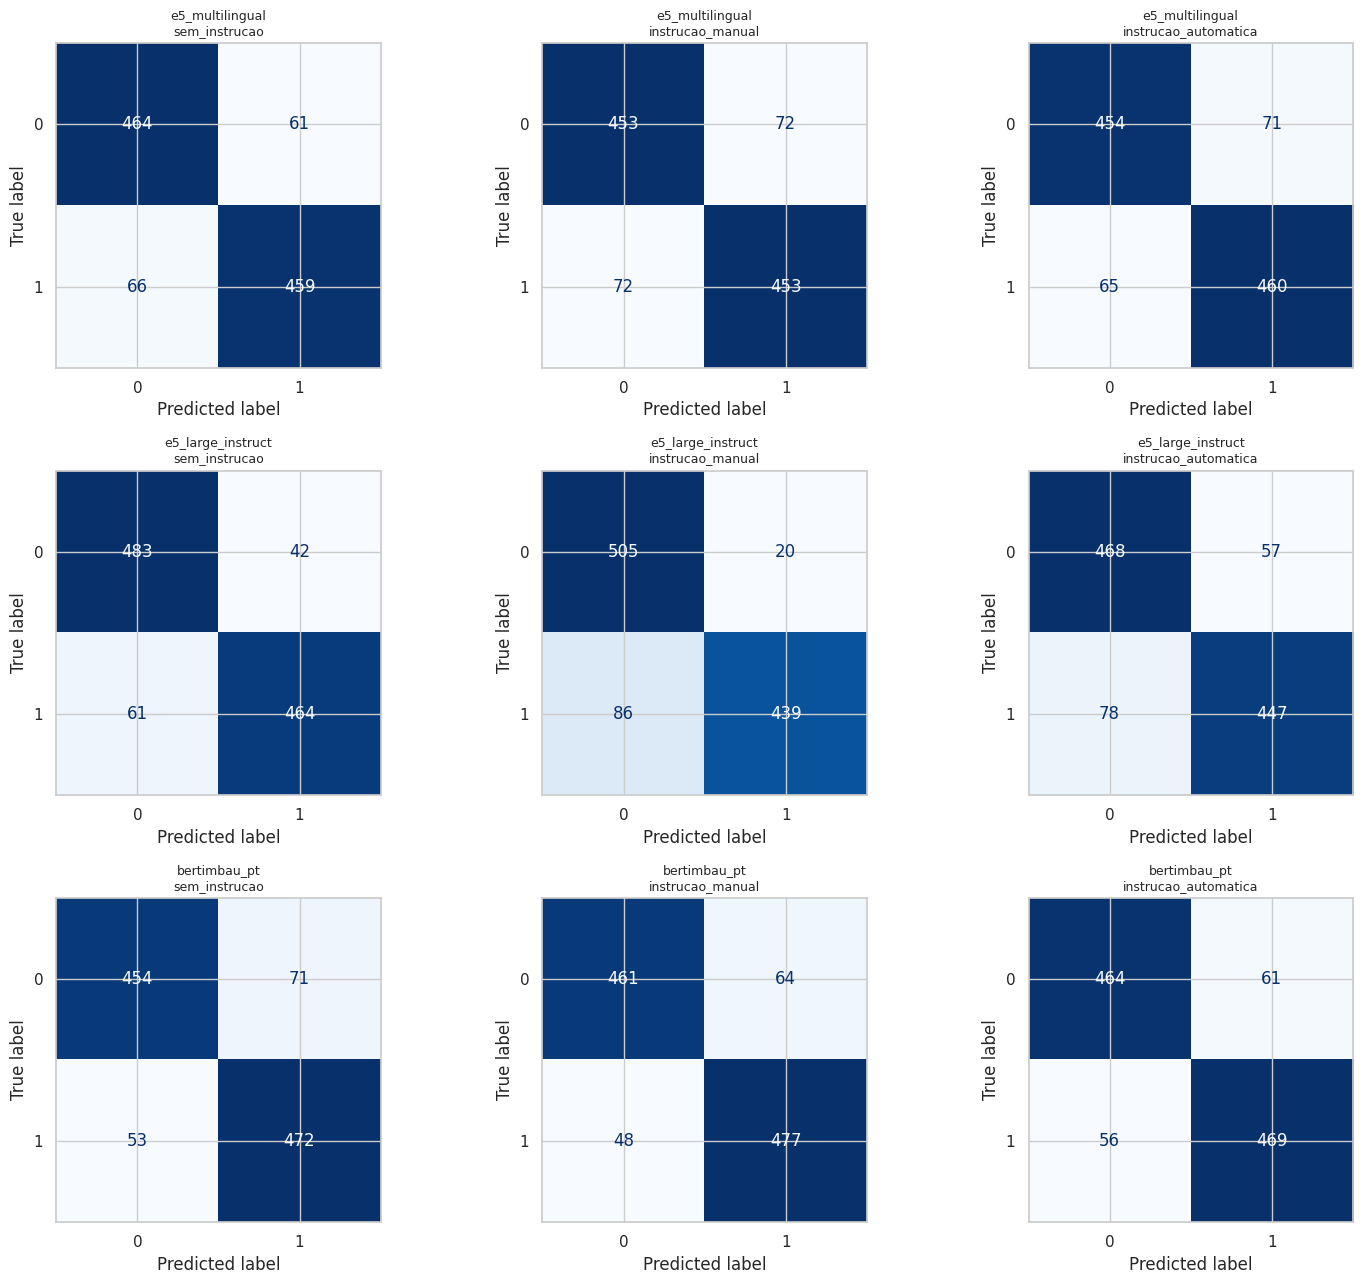

In [ ]:
# Matrizes de confusão: uma linha por modelo, uma coluna por condição
fig, axes = plt.subplots(len(MODELOS_EMBEDDING), len(CONDICOES), figsize=(15, 13))

for i, chave_modelo in enumerate(MODELOS_EMBEDDING):
    for j, condicao in enumerate(CONDICOES):
        y_pred = predicoes_teste[(chave_modelo, condicao)]
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        ax = axes[i, j]
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{chave_modelo}\n{condicao}", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Tabela-resumo: F1-macro no teste, por modelo de embeddings x condição de instrução
tabela_f1_macro = (
    df_resultados[df_resultados["split"] == "teste"]
    .pivot(index="modelo", columns="condicao", values="f1_macro")
)
tabela_f1_macro

condicao,instrucao_automatica,instrucao_manual,sem_instrucao
modelo,,,
bertimbau_pt,0.888569,0.893309,0.881870
e5_large_instruct,0.871377,0.898647,0.901873
e5_multilingual,0.870472,0.862857,0.879045


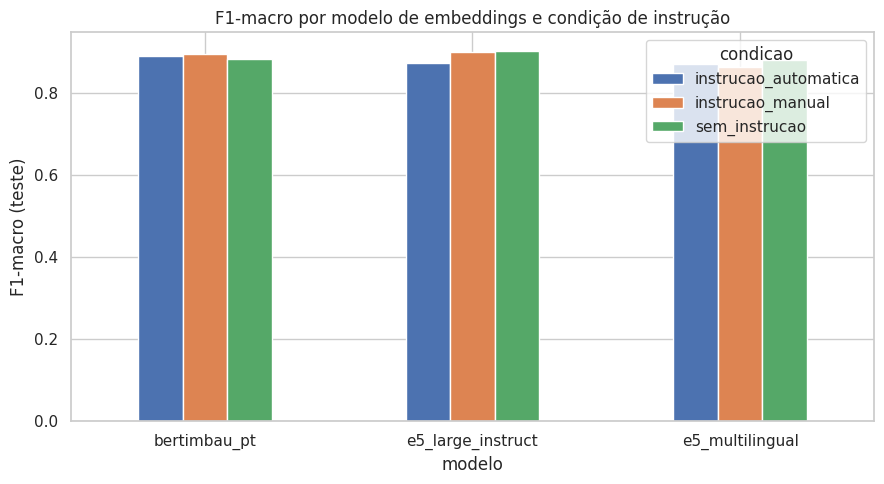

In [ ]:
tabela_f1_macro.plot(kind="bar", figsize=(9, 5))
plt.ylabel("F1-macro (teste)")
plt.title("F1-macro por modelo de embeddings e condição de instrução")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Comparação de Erros entre os Três Classificadores


In [ ]:
def conjunto_erros(chave_modelo, condicao): # Retorna o conjunto de índices (posição no split de teste) em que o modelo errou.
    y_pred = predicoes_teste[(chave_modelo, condicao)]
    return set(np.where(y_pred != y_test)[0])


modelos_lista = list(MODELOS_EMBEDDING.keys())
comparacoes_modelos = []

for condicao in CONDICOES:
    erros_por_modelo = {m: conjunto_erros(m, condicao) for m in modelos_lista}

    linha = {"condicao": condicao}
    for m in modelos_lista:
        linha[f"total_erros_{m}"] = len(erros_por_modelo[m])

    # erros exclusivos: só aquele modelo erra, os outros dois acertam
    for m in modelos_lista:
        outros = set().union(*[erros_por_modelo[o] for o in modelos_lista if o != m])
        exclusivos = erros_por_modelo[m] - outros
        linha[f"so_{m}_erra"] = len(exclusivos)

    # erro cometido pelos três modelos ao mesmo tempo (não necessariamente com a mesma predição)
    linha["erro_nos_tres_modelos"] = len(set.intersection(*erros_por_modelo.values()))

    comparacoes_modelos.append(linha)

df_comparacao_modelos = pd.DataFrame(comparacoes_modelos)
df_comparacao_modelos

,condicao,total_erros_e5_multilingual,total_erros_e5_large_instruct,total_erros_bertimbau_pt,so_e5_multilingual_erra,so_e5_large_instruct_erra,so_bertimbau_pt_erra,erro_nos_tres_modelos
0,sem_instrucao,127,103,124,43,23,47,39
1,instrucao_manual,144,106,112,62,37,44,29
2,instrucao_automatica,136,135,117,29,29,40,48


## 9. Erros Idênticos entre os Três Classificadores

**Ressalva:** como o bertimbau_pt não segue instrução, quando ele participa de um erro
idêntico isso é mais um indício de que o comentário é intrinsecamente difícil de classificar
(independente de instrução), e não necessariamente que a instrução manual/automática o confundiu.
A conclusão sobre a instrução em si deve se apoiar principalmente nos casos em que e5_multilingual e e5_large_instruct (os dois modelos instrucionais) concordam no erro.

In [ ]:
def erros_identicos(condicao): # Índices (no split de teste) em que os três modelos preveem o mesmo rótulo, e ele está errado.
    preds = {m: predicoes_teste[(m, condicao)] for m in modelos_lista}

    indices = []
    for idx in range(len(y_test)):
        preds_idx = [preds[m][idx] for m in modelos_lista]
        if len(set(preds_idx)) == 1 and preds_idx[0] != y_test[idx]:
            indices.append(idx)
    return indices

In [ ]:
MAX_EXIBIDOS = 15

for condicao in ["instrucao_manual", "instrucao_automatica"]:
    idxs = erros_identicos(condicao)
    print(f"\n=== Erros idênticos entre os três modelos | condição: {condicao} ===")
    print(f"Total de casos: {len(idxs)} de {len(y_test)} comentários no teste\n")

    for idx in idxs[:MAX_EXIBIDOS]:
        comentario = test.iloc[idx][TEXT_COL]
        rotulo_real = y_test[idx]
        predito_comum = predicoes_teste[(modelos_lista[0], condicao)][idx]

        print(f"Comentário: {comentario}")
        print(f"Rótulo real: {rotulo_real} | Predição idêntica nos 3 modelos: {predito_comum}")

        if condicao == "instrucao_manual":
            print(f"Instrução manual (EN, usada nos modelos instrucionais e5_multilingual/e5_large_instruct): {manual_instruction_en}")
            print(f"Instrução manual (PT, usada em BERTimbau): {manual_instruction_pt}")
        else:
            inst_en = instrucoes_auto["en"]["test"].get(comentario)
            inst_pt = instrucoes_auto["pt"]["test"].get(comentario)
            print(f"Instrução automática (EN, usada nos modelos instrucionais e5_multilingual/e5_large_instruct): {inst_en}")
            print(f"Instrução automática (PT, usada em BERTimbau): {inst_pt}")

        print("-" * 80)

    if len(idxs) > MAX_EXIBIDOS:
        print(f"... e mais {len(idxs) - MAX_EXIBIDOS} caso(s) não exibido(s).")


=== Erros idênticos entre os três modelos | condição: instrucao_manual ===
Total de casos: 29 de 1050 comentários no teste

Comentário: Pra todos nós que Samos milhões de negros nessi país incruindo eu esse miZeravel tem que ser punido pela lei isso e inaceitável🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷🇧🇷
Rótulo real: 1 | Predição idêntica nos 3 modelos: 0
Instrução manual (EN, usada nos modelos instrucionais e5_multilingual/e5_large_instruct): Represent the following Brazilian Portuguese comment for hate speech detection. Pay attention to insults, discrimination, prejudice, attacks against minorities and offensive language.
Instrução manual (PT, usada em BERTimbau): Represente o seguinte comentário em português brasileiro para detecção de discurso de ódio. Preste atenção a insultos, discriminação, preconceito, ataques a minorias e linguagem ofensiva.
--------------------------------------------------------------------------------
Comentário: Benedita não se altere porque esse ato cometido foi por gente que tem

In [ ]:
def erros_identicos_modelos_instrucionais(condicao): # considerando só os modelos que seguem instrução (e5_multilingual e e5_large_instruct)
    preds = {m: predicoes_teste[(m, condicao)] for m in MODELOS_INSTRUCIONAIS}

    indices = []
    for idx in range(len(y_test)):
        preds_idx = [preds[m][idx] for m in MODELOS_INSTRUCIONAIS]
        if len(set(preds_idx)) == 1 and preds_idx[0] != y_test[idx]:
            indices.append(idx)
    return indices


for condicao in ["instrucao_manual", "instrucao_automatica"]:
    idxs_instrucionais = erros_identicos_modelos_instrucionais(condicao)
    print(f"[Só modelos instrucionais: {MODELOS_INSTRUCIONAIS}] "
          f"Erros idênticos | {condicao}: {len(idxs_instrucionais)} de {len(y_test)} comentários")

[Só modelos instrucionais: ['e5_multilingual', 'e5_large_instruct']] Erros idênticos | instrucao_manual: 56 de 1050 comentários
[Só modelos instrucionais: ['e5_multilingual', 'e5_large_instruct']] Erros idênticos | instrucao_automatica: 92 de 1050 comentários


In [ ]:
def erros_identicos_df(condicao):
    idxs = erros_identicos(condicao)
    df = test.iloc[idxs][[TEXT_COL, LABEL_COL]].copy()
    df["predicao_comum_3_modelos"] = [predicoes_teste[(modelos_lista[0], condicao)][i] for i in idxs]
    df["condicao"] = condicao
    return df.reset_index(drop=True)


erros_identicos_manual_df = erros_identicos_df("instrucao_manual")
erros_identicos_auto_df = erros_identicos_df("instrucao_automatica")

print(f"Erros idênticos (instrução manual): {len(erros_identicos_manual_df)} casos")
print(f"Erros idênticos (instrução automática): {len(erros_identicos_auto_df)} casos")

Erros idênticos (instrução manual): 29 casos
Erros idênticos (instrução automática): 48 casos


## 10. Análise de Erros

Foco no ponto central da hipótese do artigo: em quais comentários a instrução automática erra e a manual acerta (e vice-versa). Esses casos são os candidatos naturais para a categorização por tipo de comentário (explícito, irônico, implícito).

**Ressalva:** os resultados de e5_multilingual e e5_large_instruct são diretamente comparáveis
entre si (ambos seguem instrução). Já os números de bertimbau_pt nesta seção devem ser lidos como
"o que acontece quando se concatena esse texto ao comentário", não como "o quão boa é a instrução",
já que o modelo não foi treinado para usar instrução.


In [ ]:
def analisar_erros_manual_vs_auto(chave_modelo):
    erros = test.copy().reset_index(drop=True)
    pred_manual = predicoes_teste[(chave_modelo, "instrucao_manual")]
    pred_auto = predicoes_teste[(chave_modelo, "instrucao_automatica")]

    erros["pred_instrucao_manual"] = pred_manual
    erros["pred_instrucao_automatica"] = pred_auto
    erros["erro_manual"] = erros[LABEL_COL] != erros["pred_instrucao_manual"]
    erros["erro_automatica"] = erros[LABEL_COL] != erros["pred_instrucao_automatica"]

    so_auto_erra = erros[erros["erro_automatica"] & ~erros["erro_manual"]]
    so_manual_erra = erros[erros["erro_manual"] & ~erros["erro_automatica"]]

    print(f"--- Modelo: {chave_modelo} ---")
    print(f"Total de comentários no teste: {len(erros)}")
    print(f"Casos em que SÓ a instrução automática erra: {len(so_auto_erra)}")
    print(f"Casos em que SÓ a instrução manual erra: {len(so_manual_erra)}\n")

    return erros, so_auto_erra, so_manual_erra

analises_erro = {}
for chave_modelo in MODELOS_EMBEDDING:
    analises_erro[chave_modelo] = analisar_erros_manual_vs_auto(chave_modelo)

--- Modelo: e5_multilingual ---
Total de comentários no teste: 1050
Casos em que SÓ a instrução automática erra: 61
Casos em que SÓ a instrução manual erra: 69

--- Modelo: e5_large_instruct ---
Total de comentários no teste: 1050
Casos em que SÓ a instrução automática erra: 68
Casos em que SÓ a instrução manual erra: 39

--- Modelo: bertimbau_pt ---
Total de comentários no teste: 1050
Casos em que SÓ a instrução automática erra: 51
Casos em que SÓ a instrução manual erra: 46



In [ ]:
# PRA FAZER: categorizar manualmente estes comentários por tipo (explícito / irônico / implícito)
erros_df_e5, so_auto_erra_e5, so_manual_erra_e5 = analises_erro["e5_multilingual"]
so_auto_erra_e5[[TEXT_COL, LABEL_COL, "pred_instrucao_manual", "pred_instrucao_automatica"]].head(20)

,comentario,label_final,pred_instrucao_manual,pred_instrucao_automatica
6,👏👏👏👏o capeta sendo capeta. Normal.,1,1,0
48,E os diretos morais? Processe os canalhas!,1,1,0
74,O mineiro fala um dito popular muito bem aplicado aos filhos do Presidente: Quem fala demais da bom dia a cavalo!,0,0,1
97,"Será,,Kkkk,,,,vcs mentem tanto mais tanto,,,,,parabéns Bolsonaro senta lenha",1,1,0
138,"Boa a fala do presidente, parem de dar moral pra essa pirralha, inclusive a senhora deputada.",1,1,0
162,"""Vcs que fazem parte dessa massa"" 😞",0,0,1
184,Demorou pra colocar esse ser na cadeia novamente,1,1,0
211,"Que bom que,as máscaras estão caindo rápido.",1,1,0
242,Correta afirmação! Estao areimando argumentos e justificativas para os contrarios usarem de artificio para derruba los,0,0,1
245,"Se fosse o Pabllo Vittar , os lacradores: ""Linda"" , ""Essa mulher nos representa"" , ""Ninguém solta a mão de ninguém"" ...",0,0,1


## Teste de Configuração e modelos diferentes
O registro distingue suporte ao português de suporte a instruções livres.

In [ ]:
SEED = 42
TEXT_COL = "comentario"
LABEL_COL = "label_final"
ID_COL = "id"

SEM_INSTRUCAO = "sem_instrucao"
MANUAL_EN = "manual_en"
MANUAL_PT = "manual_pt"
AUTOMATICA_EN = "automatica_en"
AUTOMATICA_PT = "automatica_pt"

TODAS_CONDICOES = (
    SEM_INSTRUCAO,
    MANUAL_EN,
    MANUAL_PT,
    AUTOMATICA_EN,
    AUTOMATICA_PT,
)
CONDICOES_INSTRUCIONAIS = frozenset(
    {MANUAL_EN, MANUAL_PT, AUTOMATICA_EN, AUTOMATICA_PT}
)

REQUIRED_COLUMNS = {
    ID_COL,
    TEXT_COL,
    "anotator1",
    "anotator2",
    "anotator3",
    LABEL_COL,
    "links_post",
    "account_post",
}

MANUAL_INSTRUCTIONS = {
    "en": (
        "Represent the Brazilian Portuguese comment for hate speech detection. "
        "Consider insults, discrimination, prejudice, attacks on protected groups, "
        "irony, implicit hostility, and offensive language."
    ),
    "pt": (
        "Represente o comentário em português brasileiro para detecção de discurso "
        "de ódio. Considere insultos, discriminação, preconceito, ataques a grupos "
        "protegidos, ironia, hostilidade implícita e linguagem ofensiva."
    ),
}


@dataclass(frozen=True, slots=True)
class ModelConfig:
    """Protocolo e metadados de um encoder."""

    name: str
    hf_id: str
    input_style: str
    supports_instructions: bool
    language_scope: str
    dimensions: int
    max_tokens: int
    role: str
    source_url: str

    def supports_condition(self, condition: str) -> bool:
        if condition == SEM_INSTRUCAO:
            return True
        return self.supports_instructions and condition in CONDICOES_INSTRUCIONAIS


MODEL_REGISTRY: dict[str, ModelConfig] = {
    "e5_base": ModelConfig(
        name="e5_base",
        hf_id="intfloat/multilingual-e5-base",
        input_style="e5_query",
        supports_instructions=False,
        language_scope="Multilíngue (100 idiomas; inclui português via XLM-R)",
        dimensions=768,
        max_tokens=512,
        role="Controle E5 multilíngue sem instrução livre",
        source_url="https://huggingface.co/intfloat/multilingual-e5-base",
    ),
    "e5_large_instruct": ModelConfig(
        name="e5_large_instruct",
        hf_id="intfloat/multilingual-e5-large-instruct",
        input_style="e5_instruct",
        supports_instructions=True,
        language_scope="Multilíngue (100 idiomas; inclui português via XLM-R)",
        dimensions=1024,
        max_tokens=512,
        role="Modelo instrucional principal",
        source_url="https://huggingface.co/intfloat/multilingual-e5-large-instruct",
    ),
    "minilm_multilingual": ModelConfig(
        name="minilm_multilingual",
        hf_id="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        input_style="plain",
        supports_instructions=False,
        language_scope="Multilíngue (50 idiomas)",
        dimensions=384,
        max_tokens=128,
        role="Controle multilíngue leve para execução rápida",
        source_url=(
            "https://huggingface.co/sentence-transformers/"
            "paraphrase-multilingual-MiniLM-L12-v2"
        ),
    ),
    "mpnet_multilingual": ModelConfig(
        name="mpnet_multilingual",
        hf_id="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
        input_style="plain",
        supports_instructions=False,
        language_scope="Multilíngue (50 idiomas)",
        dimensions=768,
        max_tokens=128,
        role="Controle multilíngue independente da família E5",
        source_url=(
            "https://huggingface.co/sentence-transformers/"
            "paraphrase-multilingual-mpnet-base-v2"
        ),
    ),
    "bertimbau_sts": ModelConfig(
        name="bertimbau_sts",
        hf_id="rufimelo/bert-large-portuguese-cased-sts",
        input_style="plain",
        supports_instructions=False,
        language_scope="Português brasileiro",
        dimensions=1024,
        max_tokens=128,
        role="Controle monolíngue ajustado para similaridade textual",
        source_url="https://huggingface.co/rufimelo/bert-large-portuguese-cased-sts",
    ),
    "bge_m3": ModelConfig(
        name="bge_m3",
        hf_id="BAAI/bge-m3",
        input_style="plain",
        supports_instructions=False,
        language_scope="Multilíngue (mais de 100 idiomas)",
        dimensions=1024,
        max_tokens=8192,
        role="Controle multilíngue moderno e independente",
        source_url="https://huggingface.co/BAAI/bge-m3",
    ),
}

DEFAULT_MODELS = ("e5_base", "e5_large_instruct", "minilm_multilingual")
DEFAULT_CONDITIONS = (SEM_INSTRUCAO, MANUAL_EN, MANUAL_PT)



In [ ]:
display(pd.DataFrame([{"nome":c.name,"huggingface_id":c.hf_id,"idiomas":c.language_scope,"aceita_instrucoes":c.supports_instructions,"dimensoes":c.dimensions,"papel":c.role} for c in MODEL_REGISTRY.values()]))

,nome,huggingface_id,idiomas,aceita_instrucoes,dimensoes,papel
0,e5_base,intfloat/multilingual-e5-base,Multilíngue (100 idiomas; inclui português via XLM-R),False,768,Controle E5 multilíngue sem instrução livre
1,e5_large_instruct,intfloat/multilingual-e5-large-instruct,Multilíngue (100 idiomas; inclui português via XLM-R),True,1024,Modelo instrucional principal
2,minilm_multilingual,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,Multilíngue (50 idiomas),False,384,Controle multilíngue leve para execução rápida
3,mpnet_multilingual,sentence-transformers/paraphrase-multilingual-mpnet-base-v2,Multilíngue (50 idiomas),False,768,Controle multilíngue independente da família E5
4,bertimbau_sts,rufimelo/bert-large-portuguese-cased-sts,Português brasileiro,False,1024,Controle monolíngue ajustado para similaridade textual
5,bge_m3,BAAI/bge-m3,Multilíngue (mais de 100 idiomas),False,1024,Controle multilíngue moderno e independente


### Fontes dos modelos
- [E5-base multilíngue](https://huggingface.co/intfloat/multilingual-e5-base)
- [E5-large-instruct](https://huggingface.co/intfloat/multilingual-e5-large-instruct)
- [MiniLM multilíngue](https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
- [MPNet multilíngue](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2)
- [BERTimbau STS](https://huggingface.co/rufimelo/bert-large-portuguese-cased-sts)
- [BGE-M3](https://huggingface.co/BAAI/bge-m3)

## 12. Ranking e gráfico comparativo

,modelo,condicao,f1_macro,accuracy
0,e5_large_instruct,sem_instrucao,0.905695,0.905714
1,e5_large_instruct,sem_instrucao,0.901873,0.901905
2,e5_large_instruct,instrucao_manual,0.898647,0.899048
3,bertimbau_pt,instrucao_manual,0.893309,0.893333
4,bertimbau_pt,instrucao_manual,0.889522,0.889524
5,bertimbau_pt,instrucao_automatica,0.888569,0.888571
6,e5_large_instruct,instrucao_manual,0.885314,0.885714
7,bertimbau_pt,sem_instrucao,0.881904,0.881905
8,bertimbau_pt,sem_instrucao,0.881870,0.881905
9,e5_multilingual,sem_instrucao,0.881853,0.881905


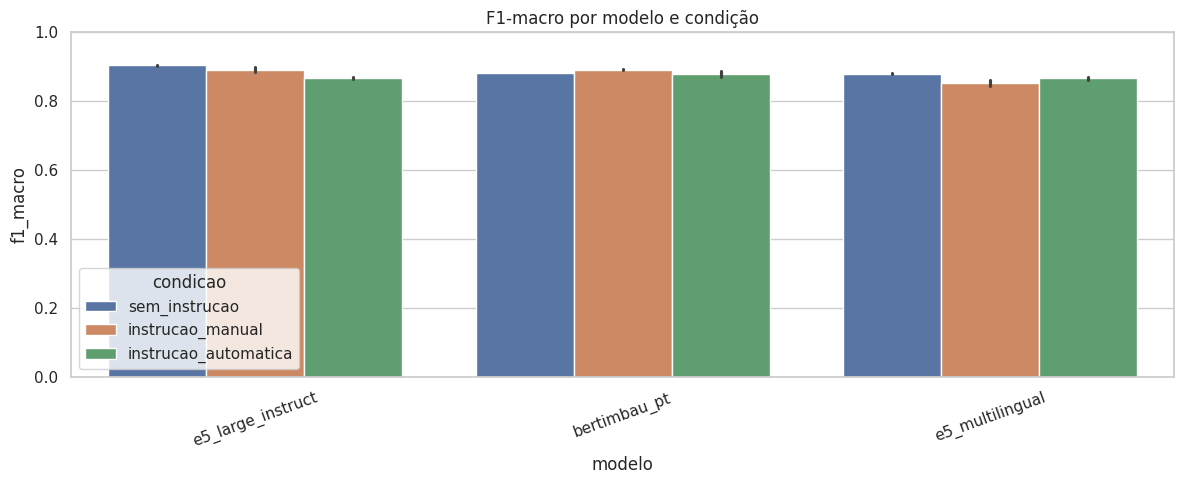

In [ ]:
r=df_resultados.sort_values("f1_macro",ascending=False).reset_index(drop=True)
display(r[["modelo","condicao","f1_macro","accuracy"]])
plt.figure(figsize=(12,5)); sns.barplot(data=r,x="modelo",y="f1_macro",hue="condicao"); plt.ylim(0,1)
plt.title("F1-macro por modelo e condição"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### Matrizes de confusão e relatórios

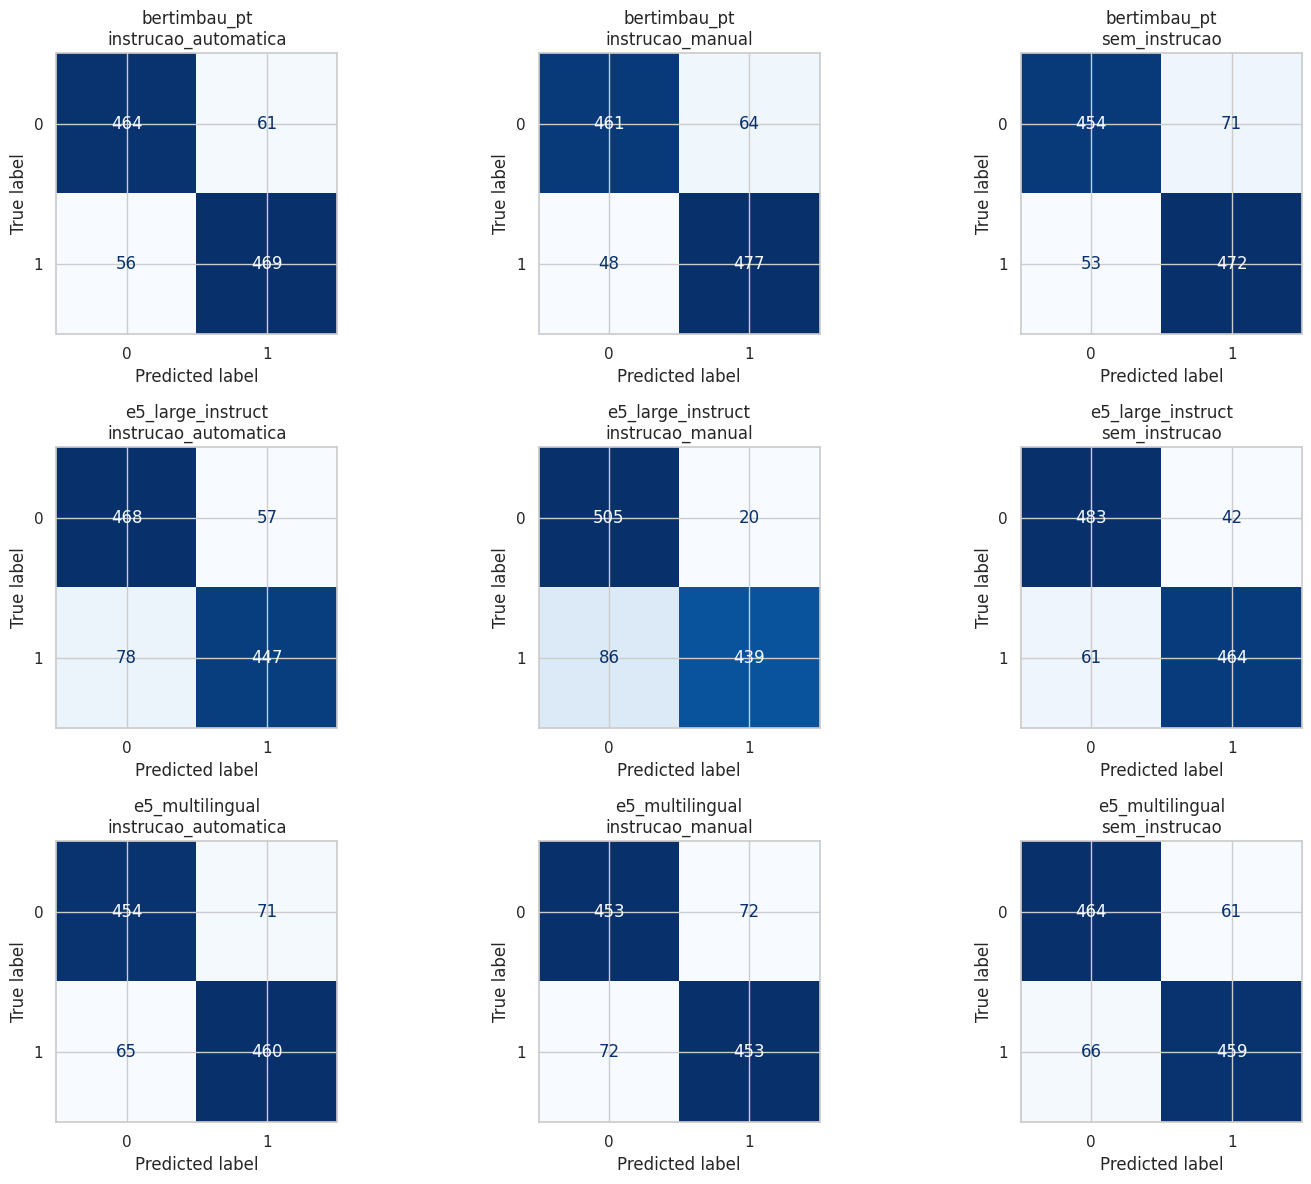


=== bertimbau_pt | instrucao_automatica ===
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       525
           1       0.88      0.89      0.89       525

    accuracy                           0.89      1050
   macro avg       0.89      0.89      0.89      1050
weighted avg       0.89      0.89      0.89      1050


=== bertimbau_pt | instrucao_manual ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       525
           1       0.88      0.91      0.89       525

    accuracy                           0.89      1050
   macro avg       0.89      0.89      0.89      1050
weighted avg       0.89      0.89      0.89      1050


=== bertimbau_pt | sem_instrucao ===
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       525
           1       0.87      0.90      0.88       525

    accuracy                           0.88      1050
   m

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report,confusion_matrix

# Construct predicoes DataFrame from existing kernel variables predicoes_teste and y_test
predicoes_list = []
for (modelo, condicao), y_preds in predicoes_teste.items():
    temp_df = pd.DataFrame({
        "modelo": modelo,
        "condicao": condicao,
        "predicao": y_preds,
        LABEL_COL: y_test # y_test contains the true labels for the test set
    })
    predicoes_list.append(temp_df)
predicoes = pd.concat(predicoes_list, ignore_index=True)

combos=list(predicoes.groupby(["modelo","condicao"]).groups)
cols=3; rows=int(np.ceil(len(combos)/cols)); fig,axes=plt.subplots(rows,cols,figsize=(5*cols,4*rows),squeeze=False)
for ax,(modelo,condicao) in zip(axes.flat,combos):
 s=predicoes.query("modelo == @modelo and condicao == @condicao"); cm=confusion_matrix(s[LABEL_COL],s.predicao,labels=[0,1])
 ConfusionMatrixDisplay(cm,display_labels=[0,1]).plot(ax=ax,cmap="Blues",colorbar=False); ax.set_title(f"{modelo}\n{condicao}")
for ax in axes.flat[len(combos):]: ax.axis("off")
plt.tight_layout(); plt.show()
for modelo,condicao in combos:
 s=predicoes.query("modelo == @modelo and condicao == @condicao"); print(f"\n=== {modelo} | {condicao} ===")
 print(classification_report(s[LABEL_COL],s.predicao,zero_division=0))

### Erros e comparação inglês vs português

In [ ]:
num_test_samples = len(test)
num_combinations = len(MODELOS_EMBEDDING) * len(CONDICOES)
if len(predicoes) != num_combinations * num_test_samples:
    raise ValueError("Mismatch in predicoes length, cannot reliably assign IDs.")

predicoes[ID_COL] = np.tile(test[ID_COL].values, num_combinations)

OUTPUT_DIR = CACHE_DIR # Define OUTPUT_DIR

detailhes=predicoes.merge(test[[ID_COL,TEXT_COL,LABEL_COL]],on=[ID_COL,LABEL_COL],how="left"); detailhes["erro"]=detailhes[LABEL_COL]!=detailhes.predicao
erros=detailhes[detailhes.erro].copy(); erros.to_csv(OUTPUT_DIR/"analise_erros_detalhada.csv",index=False)
resumo_erros=detailhes.groupby(["modelo","condicao"]).erro.agg(total_erros="sum",taxa_erro="mean").reset_index().sort_values("taxa_erro"); display(resumo_erros)
e5=detailhes.query("modelo == 'e5_large_instruct'")
if {"manual_en","manual_pt"}.issubset(set(e5.condicao)):
 comp=e5.pivot_table(index=[ID_COL,TEXT_COL,LABEL_COL],columns="condicao",values="predicao",aggfunc="first").reset_index()
 comp["predicoes_diferentes"]=comp.manual_en!=comp.manual_pt; comp["en_correta"]=comp.manual_en==comp[LABEL_COL]; comp["pt_correta"]=comp.manual_pt==comp[LABEL_COL]
 dif=comp[comp.predicoes_diferentes].copy(); dif.to_csv(OUTPUT_DIR/"comparacao_instrucao_ingles_portugues.csv",index=False)
 print("Decisões diferentes EN vs PT:",len(dif)); display(dif.head(30))

,modelo,condicao,total_erros,taxa_erro
5,e5_large_instruct,sem_instrucao,103,0.098095
4,e5_large_instruct,instrucao_manual,106,0.100952
1,bertimbau_pt,instrucao_manual,112,0.106667
0,bertimbau_pt,instrucao_automatica,117,0.111429
2,bertimbau_pt,sem_instrucao,124,0.118095
8,e5_multilingual,sem_instrucao,127,0.120952
3,e5_large_instruct,instrucao_automatica,135,0.128571
6,e5_multilingual,instrucao_automatica,136,0.129524
7,e5_multilingual,instrucao_manual,144,0.137143


## 11. Salvando Resultados

In [ ]:
df_resultados.to_csv("resultados_comparativos.csv", index=False)
df_comparacao_modelos.to_csv("comparacao_erros_entre_modelos.csv", index=False)
erros_identicos_manual_df.to_csv(CACHE_DIR / "erros_identicos_instrucao_manual.csv", index=False)
erros_identicos_auto_df.to_csv(CACHE_DIR / "erros_identicos_instrucao_automatica.csv", index=False)

for chave_modelo, (erros_df, _, _) in analises_erro.items():
    erros_df.to_csv(CACHE_DIR / f"analise_erros_{chave_modelo}.csv", index=False)

with open("modelos_treinados.pkl", "wb") as f:
    pickle.dump(classificadores, f)

print("Resultados, comparações entre modelos, erros idênticos e classificadores salvos.")

Resultados, comparações entre modelos, erros idênticos e classificadores salvos.


In [ ]:
import shutil
from IPython.display import FileLink

zip_filename = "cache.zip"
shutil.make_archive(CACHE_DIR, 'zip', CACHE_DIR)

print(f"A pasta '{CACHE_DIR}' foi compactada para '{zip_filename}'.")
display(FileLink(zip_filename))

A pasta 'cache' foi compactada para 'cache.zip'.


/content/cache.zip